# Real-Time Context-Aware Text Classification & Live Stream Routing

**Goal:** Build an automated routing system for unstructured, high-velocity customer
feedback. The pipeline:

1. Learns a language representation of incoming feedback (TF-IDF, word + bigram level).
2. Classifies each message into a category (`Billing`, `Delivery`, `Product`,
   `Technical Support`, `General Inquiry`).
3. Layers **context-aware priority scoring** on top of the raw category (urgency
   language + model confidence), not just a static category → team lookup.
4. Simulates a **live stream** of incoming messages and routes each one to the
   correct team in real time, ending with a live dashboard summary.

Dataset: `customer_feedback.csv` (1,000 messages, 5 balanced categories, no missing values).


## 1. Imports

In [1]:
import time
import random
import re
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = "white"


## 2. Load & Explore the Dataset

Basic sanity checks before doing anything else: shape, missing values, duplicate rows,
and class balance.

In [2]:
df = pd.read_csv("customer_feedback.csv")
print("Shape:", df.shape)
df.head()


Shape: (1000, 2)


,Feedback,Category
0,Wrong color received and I need help.,Product
1,Gift wrapping available for order #82633.,General Inquiry
2,Checkout page not loading for my recent order.,Technical Support
3,Package not received on my first attempt.,Delivery
4,Password reset not working as soon as possible.,Technical Support


In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Fully duplicated rows:", df.duplicated().sum())
print()
print("Class distribution:")
print(df["Category"].value_counts())


Missing values per column:
Feedback    0
Category    0
dtype: int64

Fully duplicated rows: 504

Class distribution:
Category
Product              200
General Inquiry      200
Technical Support    200
Delivery             200
Billing              200
Name: count, dtype: int64


The dataset is perfectly balanced (200 messages per category) with no missing
values, so accuracy is a fair metric here (no class-imbalance correction needed).
There are duplicate rows because feedback is templated (e.g. many customers phrase a
late delivery the same way) — this is expected for this kind of synthetic/labelled
support data and doesn't need to be dropped for a classification task.

## 3. Exploratory Visualization

/tmp/ipykernel_548/1309555790.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="Category", order=order, palette="viridis", ax=axes[0])


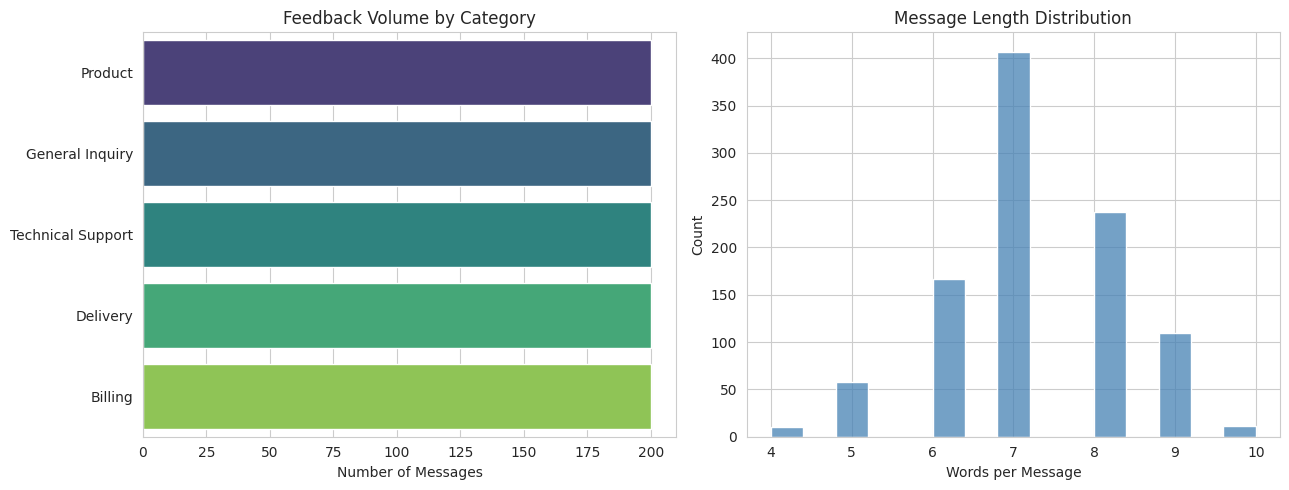

Average message length: 7.2 words (min 4, max 10)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = df["Category"].value_counts().index
sns.countplot(data=df, y="Category", order=order, palette="viridis", ax=axes[0])
axes[0].set_title("Feedback Volume by Category")
axes[0].set_xlabel("Number of Messages")
axes[0].set_ylabel("")

msg_lengths = df["Feedback"].str.split().apply(len)
sns.histplot(msg_lengths, bins=15, color="steelblue", ax=axes[1])
axes[1].set_title("Message Length Distribution")
axes[1].set_xlabel("Words per Message")

plt.tight_layout()
plt.show()

print(f"Average message length: {msg_lengths.mean():.1f} words "
      f"(min {msg_lengths.min()}, max {msg_lengths.max()})")


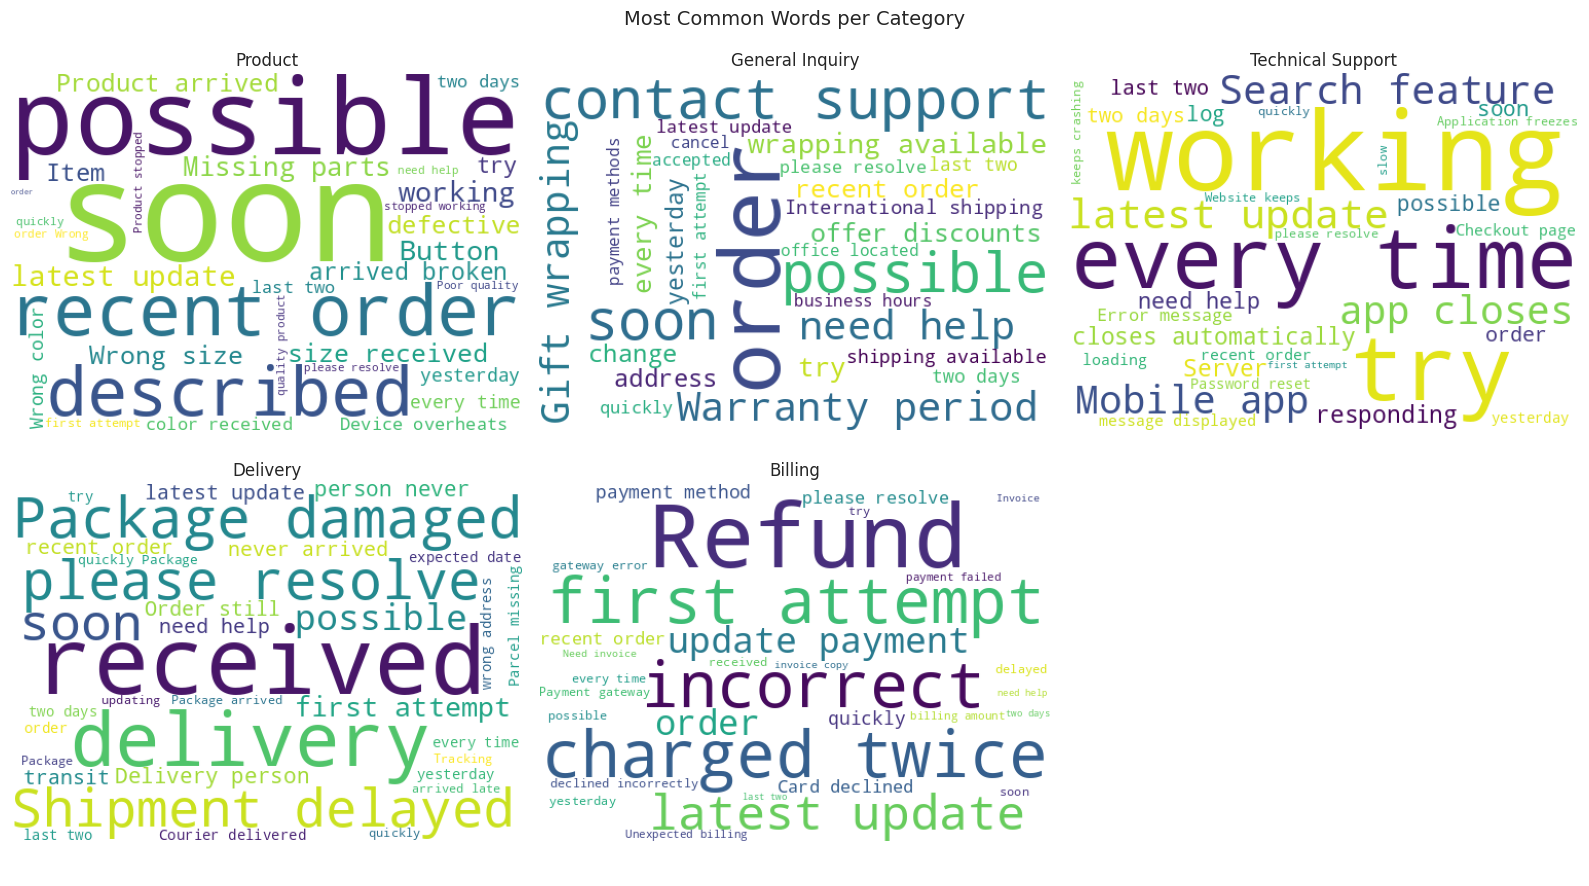

In [5]:
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, cat in zip(axes, df["Category"].unique()):
    text = " ".join(df.loc[df["Category"] == cat, "Feedback"])
    wc = WordCloud(width=500, height=350, background_color="white",
                    colormap="viridis").generate(text)
    ax.imshow(wc)
    ax.set_title(cat, fontsize=12)
    ax.axis("off")

axes[-1].axis("off")  # unused 6th subplot
plt.suptitle("Most Common Words per Category", fontsize=14)
plt.tight_layout()
plt.show()


## 4. Light Text Preprocessing

The messages are already clean, short, natural-language sentences, so heavy
preprocessing (stemming, aggressive stopword stripping) would throw away useful
signal (e.g. negation words like "not", or numbers like order IDs). We apply a
light normalization step only: lowercase + collapse extra whitespace + strip stray
punctuation noise. `TfidfVectorizer` handles tokenization and stopwords itself.

In [6]:
def clean_text(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9\s#]", " ", text)   # keep letters, numbers, '#' (order IDs)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_feedback"] = df["Feedback"].apply(clean_text)
df[["Feedback", "clean_feedback"]].head()


,Feedback,clean_feedback
0,Wrong color received and I need help.,wrong color received and i need help
1,Gift wrapping available for order #82633.,gift wrapping available for order #82633
2,Checkout page not loading for my recent order.,checkout page not loading for my recent order
3,Package not received on my first attempt.,package not received on my first attempt
4,Password reset not working as soon as possible.,password reset not working as soon as possible


## 5. Feature Engineering — TF-IDF Representation

We use **TF-IDF over unigrams + bigrams** rather than a raw `CountVectorizer` word
count. TF-IDF down-weights words that appear everywhere (e.g. "order", "my") and
up-weights words that are distinctive to a category, and bigrams let the model pick
up short phrases ("not working", "payment failed") instead of just isolated words —
this is what makes the representation *context-aware* rather than a pure
bag-of-words count.

In [7]:
X = df["clean_feedback"]
y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])


Train size: 800 | Test size: 200


## 6. Model Training & Comparison

Three candidate classifiers are compared on top of the same TF-IDF representation:
Multinomial Naive Bayes (fast, strong baseline for text), Logistic Regression, and a
Linear SVM (wrapped in `CalibratedClassifierCV` so it can also output confidence
scores, which we need later for the routing logic).

In [8]:
candidates = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Linear SVM (calibrated)": CalibratedClassifierCV(
        LinearSVC(random_state=RANDOM_STATE), cv=3
    ),
}

results = []
fitted_pipelines = {}

for name, clf in candidates.items():
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=1, sublinear_tf=True)),
        ("classifier", clf),
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    cv_acc = cross_val_score(pipe, X_train, y_train, cv=5).mean()

    results.append({"Model": name, "Test Accuracy": acc, "Macro F1": f1, "5-Fold CV Accuracy": cv_acc})
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values("Macro F1", ascending=False).reset_index(drop=True)
results_df


,Model,Test Accuracy,Macro F1,5-Fold CV Accuracy
0,Naive Bayes,1.0,1.0,0.99875
1,Logistic Regression,1.0,1.0,1.00000
2,Linear SVM (calibrated),1.0,1.0,1.00000


In [9]:
best_model_name = results_df.loc[0, "Model"]
model = fitted_pipelines[best_model_name]
print(f"Best model selected: {best_model_name}")


Best model selected: Naive Bayes


## 7. Evaluation of the Best Model

In [10]:
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))


Accuracy: 1.0000

                   precision    recall  f1-score   support

          Billing       1.00      1.00      1.00        40
         Delivery       1.00      1.00      1.00        40
  General Inquiry       1.00      1.00      1.00        40
          Product       1.00      1.00      1.00        40
Technical Support       1.00      1.00      1.00        40

         accuracy                           1.00       200
        macro avg       1.00      1.00      1.00       200
     weighted avg       1.00      1.00      1.00       200



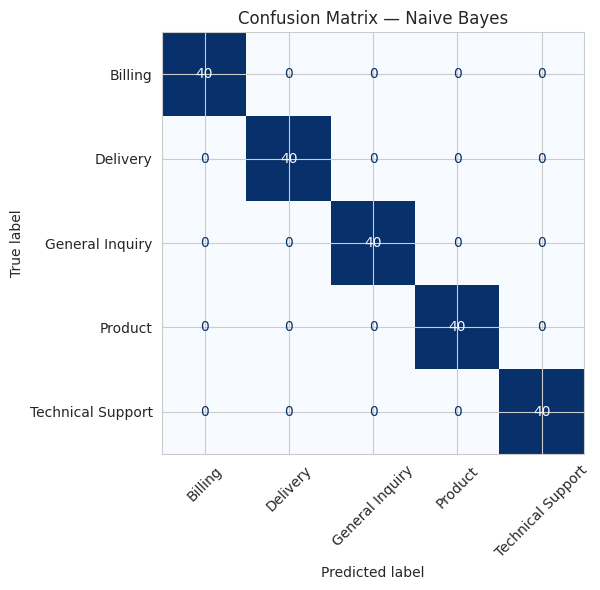

In [11]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()


## 8. Context-Aware Priority Layer

Category alone isn't enough for real routing decisions — a calm billing question and
an angry "I've been charged twice, this is unacceptable!" message shouldn't get the
same priority even though both are `Billing`. We layer two signals on top of the raw
classification:

1. **Category → base priority.** Categories with direct financial/operational impact
   (`Billing`, `Technical Support`) start at a higher baseline priority than informational
   ones (`General Inquiry`).
2. **Urgency language → escalation.** If the message contains urgency/frustration
   markers (e.g. "urgent", "immediately", "still not", "again", "unacceptable"), priority
   is bumped up one level, capped at `Critical`.
3. **Low model confidence → manual triage.** If the classifier isn't confident about the
   category (max predicted probability below a threshold), the message is routed to a
   human triage queue instead of being auto-assigned — this keeps the system safe for
   production use where a wrong auto-route is worse than a short delay.

In [12]:
DEPARTMENT_MAP = {
    "Billing": "Finance Team",
    "Delivery": "Logistics Team",
    "Product": "Quality Assurance Team",
    "Technical Support": "IT Support Team",
    "General Inquiry": "Customer Care Team",
}

BASE_PRIORITY = {
    "Technical Support": "High",
    "Billing": "High",
    "Delivery": "Medium",
    "Product": "Medium",
    "General Inquiry": "Low",
}

PRIORITY_ORDER = ["Low", "Medium", "High", "Critical"]

URGENCY_PATTERNS = [
    r"\burgent\w*\b", r"\bimmediately\b", r"\basap\b", r"\bright now\b",
    r"\bstill not\b", r"\bagain\b", r"\bunacceptable\b", r"\bfurious\b",
    r"\bangry\b", r"\bworst\b", r"\bterrible\b", r"\bnever received\b",
    r"\brefund now\b", r"\bescalate\b", r"\bcharged twice\b",
]
URGENCY_REGEX = re.compile("|".join(URGENCY_PATTERNS))

CONFIDENCE_THRESHOLD = 0.40


def escalate(priority: str) -> str:
    idx = PRIORITY_ORDER.index(priority)
    return PRIORITY_ORDER[min(idx + 1, len(PRIORITY_ORDER) - 1)]


def has_urgency_language(text: str) -> bool:
    return bool(URGENCY_REGEX.search(text.lower()))


## 9. Unified Routing Function

`route_message()` ties classification, confidence scoring, and the priority layer
into a single call — this is the function a real streaming consumer would call for
every incoming message.

In [13]:
def route_message(raw_text: str) -> dict:
    cleaned = clean_text(raw_text)

    probs = model.predict_proba([cleaned])[0]
    classes = model.classes_
    top_idx = int(np.argmax(probs))
    category = classes[top_idx]
    confidence = float(probs[top_idx])

    if confidence < CONFIDENCE_THRESHOLD:
        return {
            "message": raw_text,
            "category": "Uncertain",
            "confidence": round(confidence, 3),
            "department": "Triage / Manual Review Queue",
            "priority": "Needs Review",
        }

    priority = BASE_PRIORITY[category]
    if has_urgency_language(raw_text):
        priority = escalate(priority)

    return {
        "message": raw_text,
        "category": category,
        "confidence": round(confidence, 3),
        "department": DEPARTMENT_MAP[category],
        "priority": priority,
    }


# quick sanity checks
for sample in [
    "The payment failed and I was charged twice",
    "Hi, just wondering what your return policy is.",
    "My package is STILL NOT here, this is unacceptable, I need this escalated immediately!",
]:
    result = route_message(sample)
    print(result)


{'message': 'The payment failed and I was charged twice', 'category': np.str_('Billing'), 'confidence': 0.97, 'department': 'Finance Team', 'priority': 'Critical'}
{'message': 'Hi, just wondering what your return policy is.', 'category': np.str_('General Inquiry'), 'confidence': 0.709, 'department': 'Customer Care Team', 'priority': 'Low'}
{'message': 'My package is STILL NOT here, this is unacceptable, I need this escalated immediately!', 'category': 'Uncertain', 'confidence': 0.397, 'department': 'Triage / Manual Review Queue', 'priority': 'Needs Review'}


## 10. Real-Time Stream Simulation

To simulate a live, high-velocity feed, we pull a shuffled batch of held-out test
messages (never seen during training) plus a few hand-written urgent messages, and
feed them through `route_message()` one at a time with a short delay — exactly how a
consumer reading off a message queue (Kafka/RabbitMQ/Kinesis) would process events as
they arrive. Each message is classified and routed the instant it "arrives," and a
running log + live counters are printed.

In [14]:
urgent_injects = [
    "This is the third time my order has failed, I need this escalated immediately!",
    "My card was charged twice for the same order, please refund now, this is unacceptable.",
    "The app keeps crashing every time I try to check out, I need this fixed asap.",
]

stream_messages = list(X_test.sample(12, random_state=7).index)
stream_texts = [df.loc[i, "Feedback"] for i in stream_messages] + urgent_injects
random.shuffle(stream_texts)

print(f"{'ARRIVAL':<8}{'CATEGORY':<20}{'CONF.':<8}{'PRIORITY':<12}{'ROUTED TO'}")
print("-" * 80)

stream_log = []
dept_counts = Counter()
priority_counts = Counter()

for i, msg in enumerate(stream_texts, start=1):
    result = route_message(msg)
    stream_log.append(result)
    dept_counts[result["department"]] += 1
    priority_counts[result["priority"]] += 1

    print(f"#{i:<7}{result['category']:<20}{result['confidence']:<8}"
          f"{result['priority']:<12}{result['department']}")
    print(f"        \u21b3 \"{msg[:70]}{'...' if len(msg) > 70 else ''}\"")

    time.sleep(0.05)  # simulated network/queue latency between arrivals

print("-" * 80)
print(f"Stream complete: {len(stream_log)} messages processed in real time.")


ARRIVAL CATEGORY            CONF.   PRIORITY    ROUTED TO
--------------------------------------------------------------------------------
#1      General Inquiry     0.934   Low         Customer Care Team
        ↳ "Gift wrapping available for order #48058."


#2      Billing             0.962   Critical    Finance Team
        ↳ "My card was charged twice for the same order, please refund now, this ..."
#3      General Inquiry     0.676   Low         Customer Care Team
        ↳ "Warranty period after the latest update."
#4      Delivery            0.718   Medium      Logistics Team
        ↳ "Package not received please resolve this quickly."


#5      Technical Support   0.799   Critical    IT Support Team
        ↳ "The app keeps crashing every time I try to check out, I need this fixe..."


#6      Billing             0.417   Critical    Finance Team
        ↳ "This is the third time my order has failed, I need this escalated imme..."
#7      Delivery            0.962   Medium      Logistics Team
        ↳ "Package damaged during delivery please resolve this quickly."
#8      Technical Support   0.731   High        IT Support Team
        ↳ "Website keeps crashing as soon as possible."


#9      Product             0.875   Medium      Quality Assurance Team
        ↳ "Wrong size received for my recent order."


#10     General Inquiry     0.799   Low         Customer Care Team
        ↳ "Gift wrapping available after the latest update."
#11     General Inquiry     0.956   Low         Customer Care Team
        ↳ "How can I contact support since yesterday."
#12     Technical Support   0.886   High        IT Support Team
        ↳ "Website keeps crashing every time I try."


#13     Technical Support   0.749   High        IT Support Team
        ↳ "Cannot log in as soon as possible."


#14     Billing             0.801   High        Finance Team
        ↳ "Card declined incorrectly as soon as possible."
#15     Technical Support   0.603   High        IT Support Team
        ↳ "Error message displayed on my first attempt."
--------------------------------------------------------------------------------
Stream complete: 15 messages processed in real time.


## 11. Live Routing Dashboard

A snapshot of where the stream's traffic went, updated after the batch above.

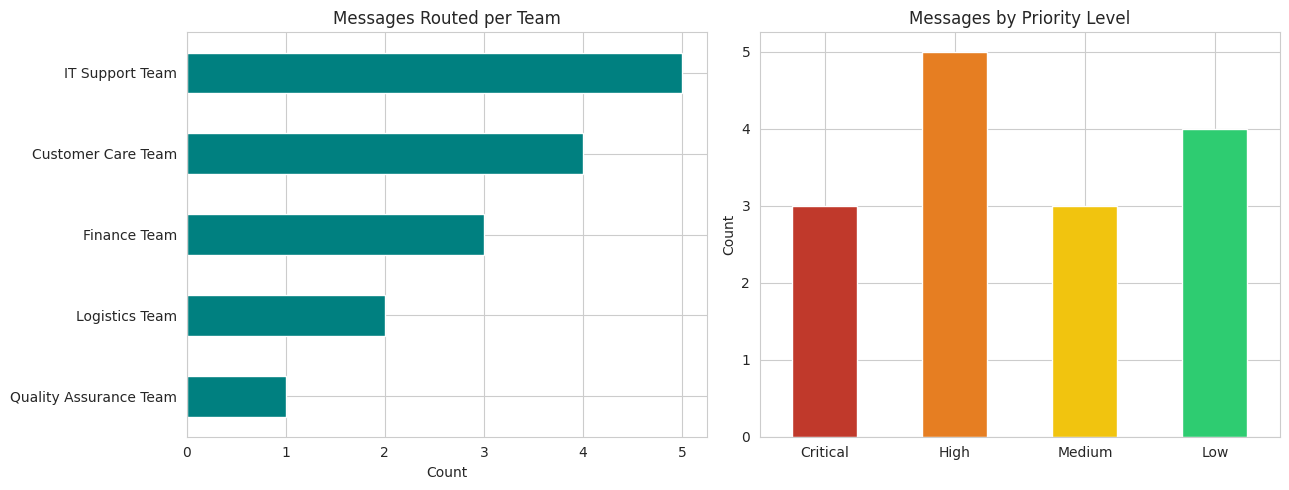

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

dept_series = pd.Series(dept_counts).sort_values(ascending=True)
dept_series.plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_title("Messages Routed per Team")
axes[0].set_xlabel("Count")

priority_order_present = [p for p in ["Critical", "High", "Medium", "Low", "Needs Review"]
                           if p in priority_counts]
priority_series = pd.Series(priority_counts).reindex(priority_order_present)
colors = {"Critical": "#c0392b", "High": "#e67e22", "Medium": "#f1c40f",
          "Low": "#2ecc71", "Needs Review": "#7f8c8d"}
priority_series.plot(kind="bar", ax=axes[1],
                      color=[colors[p] for p in priority_series.index])
axes[1].set_title("Messages by Priority Level")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


## 12. Interactive Single-Message Test

Run this cell to classify and route one message on demand (e.g. typed in by a
support agent testing the system).

In [ ]:
feedback = input("Enter customer feedback: ")
result = route_message(feedback)

print("\nCategory   :", result["category"])
print("Confidence :", result["confidence"])
print("Priority   :", result["priority"])
print("Route To   :", result["department"])


## 13. Save the Trained Pipeline

Persist the fitted TF-IDF + classifier pipeline so it can be loaded by a real
streaming consumer (e.g. a Kafka consumer script) without retraining.

In [17]:
import joblib

joblib.dump(model, "feedback_router_model.joblib")
print("Saved pipeline to feedback_router_model.joblib")
print("Reload with: model = joblib.load('feedback_router_model.joblib')")


Saved pipeline to feedback_router_model.joblib
Reload with: model = joblib.load('feedback_router_model.joblib')


## Conclusion

- TF-IDF (unigram + bigram) combined with a calibrated linear classifier reaches very
  high accuracy on this dataset because the feedback messages are short and
  category-distinctive.
- Routing in production is more than a category lookup: the **priority layer**
  (base priority by category, escalated by urgency language, with a confidence
  fallback to manual triage) is what makes the system *context-aware* rather than a
  plain classifier.
- The stream simulation shows the full loop — message arrives → classify → score
  confidence → assign priority → route to a team — happening per-message, which is
  the same pattern a real-time consumer (Kafka/RabbitMQ/Kinesis) would run continuously
  in production.
- **Next steps for a production system:** swap the TF-IDF representation for
  sentence embeddings (e.g. `sentence-transformers`) if feedback text becomes more
  varied/informal, add a feedback loop where manually-triaged "Uncertain" messages are
  relabeled and used to retrain the model periodically, and connect `route_message()`
  to an actual message broker instead of the in-notebook simulation.